# **1. Perkenalan Dataset**


Proyek ini bertujuan untuk mengelompokkan pelanggan berdasarkan perilaku transaksi menggunakan metode RFM (Recency, Frequency, Monetary) dan algoritma K-Means Clustering.
Tujuannya adalah mendukung strategi bisnis yang tepat sasaran melalui pengambilan keputusan berbasis data.

**Nama Dataset**: Online Retail Data Set.

**Sumber**: Kaggle.

**Fitur Utama**: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, dan Country.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# load data
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

In [3]:
print("5 baris Pertama")
display(df.head())

5 baris Pertama


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
print("\nINFO DATA:")
print(df.info())


INFO DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [5]:
print("\nDESKRIPSI STATISTIK:")
display(df.describe())


DESKRIPSI STATISTIK:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
# Missing Values & Duplikasi
print("\nMissing Value:")
print(df.isnull().sum())

print("\nJumlah Duplikasi:", df.duplicated().sum())


Missing Value:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Jumlah Duplikasi: 5268


In [7]:
#  Cek Nilai Unik di Kolom Penting

print("JUMLAH Nilai Unik: ")
print("Jumlah Invoice unik (transaksi berbeda):", df['InvoiceNo'].nunique())
print("Jumlah Customer unik (jumlah customer):", df['CustomerID'].nunique())
print("Jumlah Produk unik (variasi produk):", df['Description'].nunique())
print("Jumlah Kode Produk unik (variasi StockCode):", df['StockCode'].nunique())
print("Jumlah Negara unik:", df['Country'].nunique())

JUMLAH Nilai Unik: 
Jumlah Invoice unik (transaksi berbeda): 25900
Jumlah Customer unik (jumlah customer): 4372
Jumlah Produk unik (variasi produk): 4223
Jumlah Kode Produk unik (variasi StockCode): 4070
Jumlah Negara unik: 38


In [8]:
#  Datetime Analysis
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

print("\nRange Waktu Transaksi:")
print("Transaksi Pertama:", df['InvoiceDate'].min())
print("Transaksi Terakhir:", df['InvoiceDate'].max())

#  waktu
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Date'] = df['InvoiceDate'].dt.date

#  Analisis transaksi paling ramai
trans_per_hari = df.groupby('Date')['InvoiceNo'].count()
trans_per_bulan = df.groupby('Month')['InvoiceNo'].count()
trans_per_jam = df.groupby('Hour')['InvoiceNo'].count()

print("\nTanggal paling ramai:", trans_per_hari.idxmax(), "dengan", trans_per_hari.max(), "transaksi")
print("Bulan paling ramai:", trans_per_bulan.idxmax(), "dengan", trans_per_bulan.max(), "transaksi")
print("Jam paling ramai:", trans_per_jam.idxmax(), "dengan", trans_per_jam.max(), "transaksi")


Range Waktu Transaksi:
Transaksi Pertama: 2010-01-12 08:26:00
Transaksi Terakhir: 2011-12-10 17:19:00

Tanggal paling ramai: 2011-05-12 dengan 5331 transaksi
Bulan paling ramai: 11 dengan 73594 transaksi
Jam paling ramai: 12 dengan 78709 transaksi


In [9]:
#  Perhitungan Pendapatan (Revenue)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df['Revenue'] = df['Revenue'].round(2)

#  Hitung total revenue
total_revenue = df['Revenue'].sum()

print("\nTotal Revenue:", f"{total_revenue:,.2f}")


Total Revenue: 9,747,747.93


/tmp/ipython-input-4173483071.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_country.values, y=top_country.index, palette="viridis")


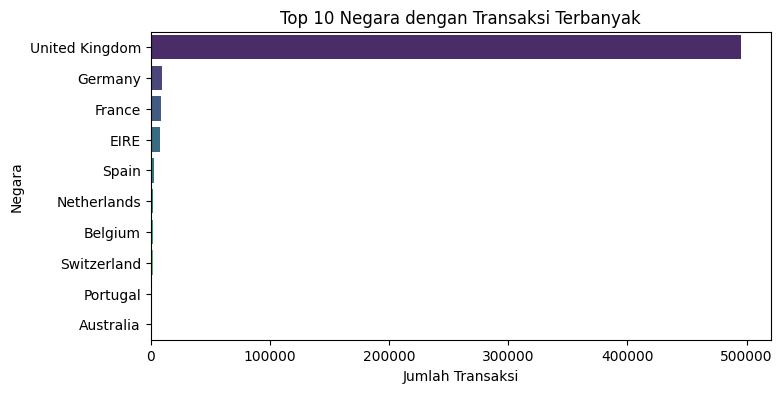

In [10]:
# Negara Terbanyak Transaksi
top_country = df['Country'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=top_country.values, y=top_country.index, palette="viridis")
plt.title("Top 10 Negara dengan Transaksi Terbanyak")
plt.xlabel("Jumlah Transaksi")
plt.ylabel("Negara")
plt.show()

/tmp/ipython-input-2183143439.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="magma")


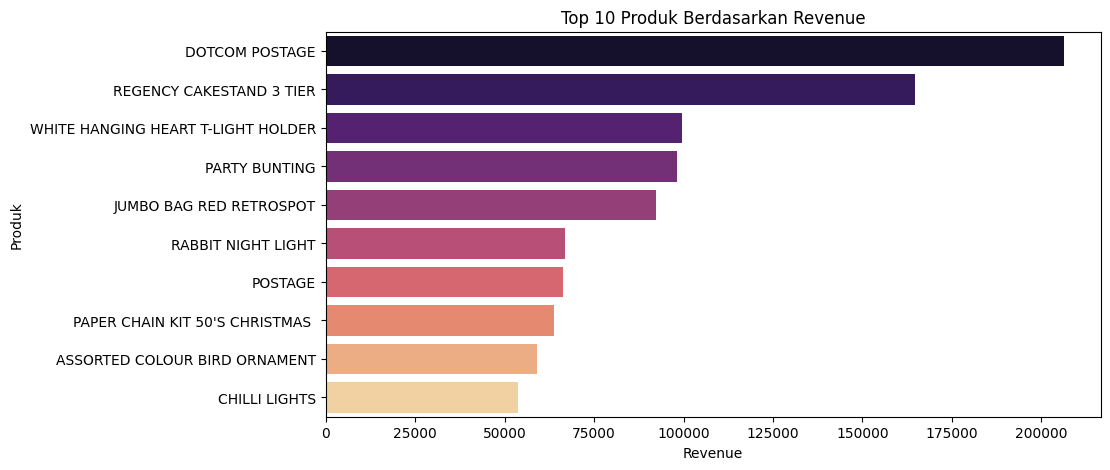

In [11]:
# Top Product berdasarkan revenue
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")
plt.title("Top 10 Produk Berdasarkan Revenue")
plt.xlabel("Revenue")
plt.ylabel("Produk")
plt.show()

In [12]:
#  Analisis Customer
#  Customer paling aktif
active_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
print("\nTop 10 Customer Paling Aktif:")
display(active_customer)

#  Customer dengan pembelian terbanyak
top_cust_qty = df.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Customer dengan Quantity Terbanyak:")
display(top_cust_qty)


Top 10 Customer Paling Aktif:


,InvoiceNo
CustomerID,
14911.0,248
12748.0,224
17841.0,169
14606.0,128
15311.0,118
13089.0,118
12971.0,89
14527.0,86
13408.0,81



Top 10 Customer dengan Quantity Terbanyak:


,Quantity
CustomerID,
14646.0,196719
12415.0,77242
14911.0,77180
17450.0,69029
18102.0,64122
17511.0,63012
13694.0,61803
14298.0,58021
14156.0,57025


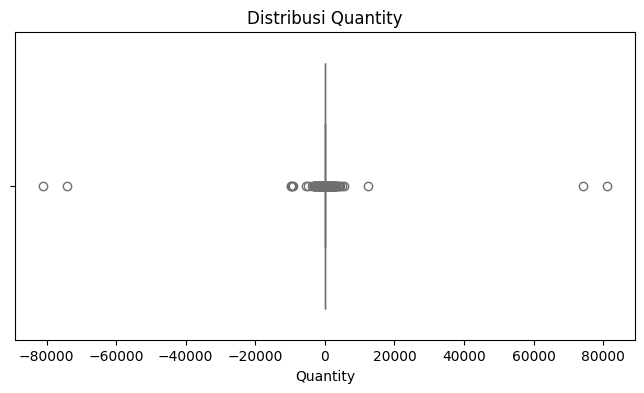

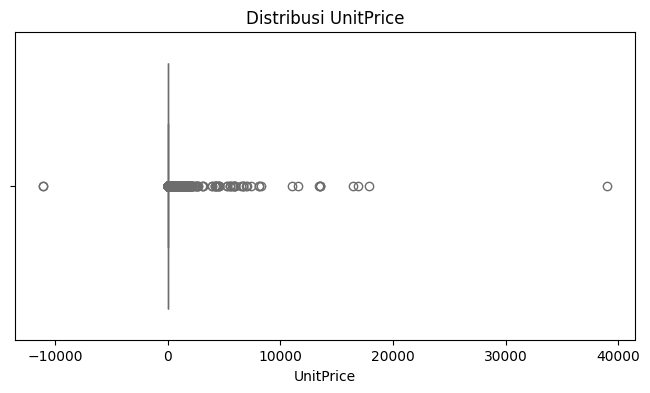

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Quantity'], color='skyblue')
plt.title("Distribusi Quantity")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df['UnitPrice'], color='salmon')
plt.title("Distribusi UnitPrice")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

**Drop Missing Value**

In [14]:
df_drop = df.dropna(subset=['CustomerID'])
df_drop['CustomerID'] = df_drop['CustomerID'].astype(int)

/tmp/ipython-input-878481258.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drop['CustomerID'] = df_drop['CustomerID'].astype(int)


**Drop Duplicate**

In [15]:
df_duplicate = df_drop.drop_duplicates()

In [16]:
print('Missing value: ', df_duplicate.isnull().sum())
print('Duplikasi: ', df_duplicate.duplicated().sum())

Missing value:  InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Year           0
Month          0
Day            0
Hour           0
Date           0
Revenue        0
dtype: int64
Duplikasi:  0


**Bersihkan Data Invalid**

In [17]:
df_step1 = df_duplicate[~df_duplicate['InvoiceNo'].astype(str).str.startswith('C')]

#  Remove quantity <= 0
df_clean = df_step1[df_step1['Quantity'] > 0]

#  Remove UnitPrice <= 0
df_clean = df_clean[df_clean['UnitPrice'] > 0]

#  Remove extreme outlier
Q1_Q = df_clean['Quantity'].quantile(0.25)
Q3_Q = df_clean['Quantity'].quantile(0.75)
IQR_Q = Q3_Q - Q1_Q

lower_Q = Q1_Q - 1.5 * IQR_Q
upper_Q = Q3_Q + 1.5 * IQR_Q

Q1_P = df_clean['UnitPrice'].quantile(0.25)
Q3_P = df_clean['UnitPrice'].quantile(0.75)
IQR_P = Q3_P - Q1_P

lower_P = Q1_P - 1.0 * IQR_P
upper_P = Q3_P + 1.0 * IQR_P

df_final = df_clean[
    (df_clean['Quantity'] >= lower_Q) & (df_clean['Quantity'] <= upper_Q) &
    (df_clean['UnitPrice'] >= lower_P) & (df_clean['UnitPrice'] <= upper_P)
]

In [18]:
df_final[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,327872.000000,327872.000000
mean,7.594247,2.117369
std,6.796011,1.435498
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.650000
75%,12.000000,2.950000
max,27.000000,6.250000


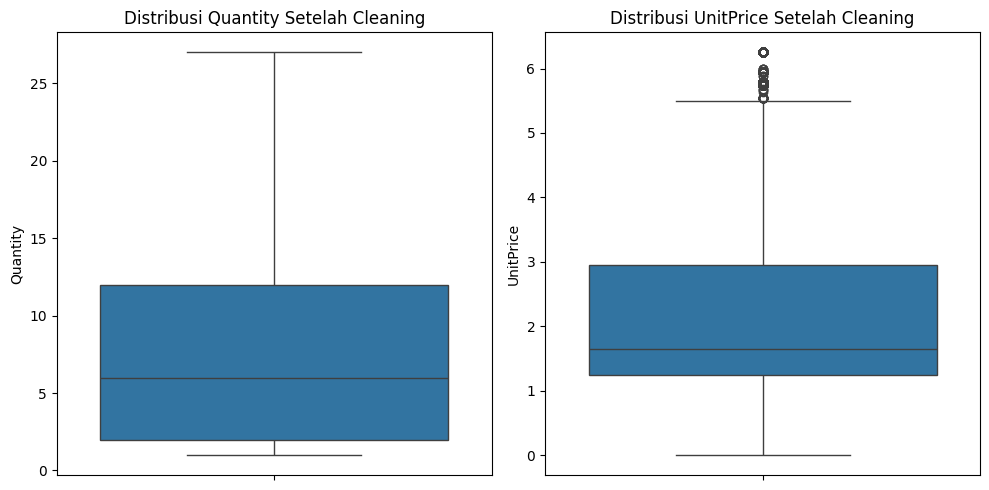

In [19]:
plt.figure(figsize=(10,5))

plt.subplot(121)
sns.boxplot(df_final['Quantity'])
plt.title("Distribusi Quantity Setelah Cleaning")

plt.subplot(122)
sns.boxplot(df_final['UnitPrice'])
plt.title("Distribusi UnitPrice Setelah Cleaning")

plt.tight_layout()
plt.show()

**Konversi InvoiceDate menjadi tipe datetime**

Agar bisa menghitung Recency di RFM dan mengurutkan data berdasarkan waktu

In [20]:
df_final1 = df_final.copy()
df_final1['InvoiceDate'] = pd.to_datetime(df_final1['InvoiceDate'])

In [21]:
df_final1['InvoiceDate'].dtype

dtype('<M8[ns]')

**Membuat Fitur TotalAmount**

In [22]:
df_final2 = df_final1.copy()
df_final2['TotalAmount'] = df_final2['Quantity'] * df_final2['UnitPrice']

In [23]:
df_final2[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [24]:
df_final2['TotalAmount'].describe()

,TotalAmount
count,327872.000000
mean,12.564722
std,12.358171
min,0.001000
25%,3.900000
50%,10.080000
75%,17.400000
max,150.000000


In [25]:
print("Jumlah customer sebelum cleaning:", df['CustomerID'].nunique())
print("Jumlah customer setelah cleaning:", df_final2['CustomerID'].nunique())

Jumlah customer sebelum cleaning: 4372
Jumlah customer setelah cleaning: 4186


In [46]:
script_content = """
import pandas as pd
import os

def run_preprocessing(input_path):
    # Load data
    df = pd.read_csv(input_path, encoding='ISO-8859-1')

    # Cleaning
    df = df.dropna(subset=['CustomerID'])
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

    # Save hasil bersih
    output_name = "OnlineRetail_preprocessed.csv"
    df.to_csv(output_name, index=False)
    print(f"Automasi Berhasil! File tersimpan: {output_name}")

if __name__ == "__main__":
    run_preprocessing('OnlineRetail.csv')
"""

with open('automate_Zeny-Arsya-Fortilla.py', 'w') as f:
    f.write(script_content)

print("File 'automate_Zeny-Arsya-Fortilla.py' telah dibuat di folder Colab.")

File 'automate_Zeny-Arsya-Fortilla.py' telah dibuat di folder Colab.


In [47]:
from google.colab import files

# Download script automasi
files.download('automate_Zeny-Arsya-Fortilla.py')

# Download data yang sudah bersih (untuk jaga-jaga)
df_clean.to_csv('OnlineRetail_preprocessed.csv', index=False)
files.download('OnlineRetail_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Membangun RFM (Recency, Frequency, Monetary)**

In [26]:
#  Tanggal referensi
ref_date = df_final2['InvoiceDate'].max()
ref_date

Timestamp('2011-12-10 17:19:00')

In [27]:
#  Tabel RFM
rfm = df_final2.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,    # Recency
    'InvoiceNo': 'nunique',                                # Frequency
    'TotalAmount': 'sum'                                   # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [28]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347,40,7,3314.73
12348,220,3,90.20
12349,19,1,984.15
12350,311,1,294.40
12352,73,7,1130.94


In [29]:
rfm.describe()

,Recency,Frequency,Monetary
count,4186.000000,4186.000000,4186.000000
mean,105.774009,3.995700,984.142478
std,114.113775,6.980429,2091.180778
min,0.000000,1.000000,1.900000
25%,22.000000,1.000000,199.065000
50%,61.000000,2.000000,452.150000
75%,162.000000,4.000000,1099.312500
max,697.000000,195.000000,82150.090000


In [30]:
#  rfm_log = np.log1p(rfm)

**Normalisasi RFM**

In [31]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    index = rfm.index,
    columns = ['Recency', 'Frequency', 'Monetary']
)

In [32]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.186000e+03,4.186000e+03,4.186000e+03
mean,-2.546140e-18,-2.206654e-17,-4.073824e-17
std,1.000119e+00,1.000119e+00,1.000119e+00
min,-9.270278e-01,-4.292083e-01,-4.697632e-01
25%,-7.342147e-01,-4.292083e-01,-3.754679e-01
50%,-3.924097e-01,-2.859335e-01,-2.544285e-01
75%,4.927776e-01,6.160884e-04,5.508074e-02
max,5.181641e+00,2.736610e+01,3.881809e+01


<Axes: ylabel='Monetary'>

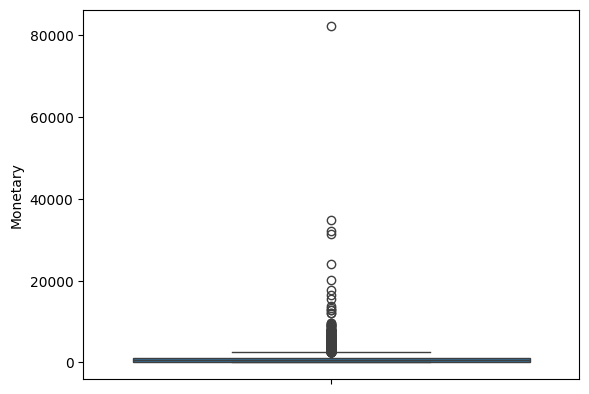

In [33]:
sns.boxplot(rfm['Monetary'])

**Elbow Method**

In [34]:
# Range Jumlah Cluster (K)
k_range = range(2,11)

inertia_list = []

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(rfm_scaled_df)
  inertia_list.append(kmeans.inertia_)

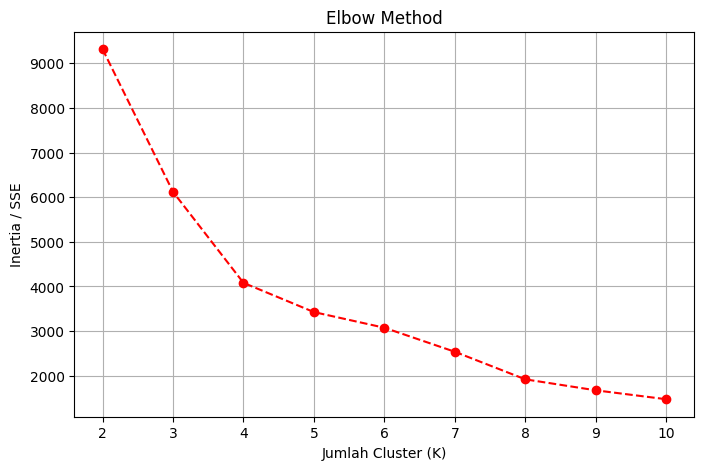

In [35]:
# Plot Elbow
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia_list, marker='o', linestyle='--', color='red')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia / SSE')
plt.xticks(k_range)
plt.grid(True)
plt.show()

**Silhouette Score**

In [36]:
X = rfm_scaled_df

silhouette_scores = []
K = range(2, 11)

print("Silhouette Score untuk setiap jumlah cluster:")
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"K = {k}: Silhouette Score = {score:.4f}")


Silhouette Score untuk setiap jumlah cluster:
K = 2: Silhouette Score = 0.4697
K = 3: Silhouette Score = 0.4819
K = 4: Silhouette Score = 0.5361
K = 5: Silhouette Score = 0.4824
K = 6: Silhouette Score = 0.4061
K = 7: Silhouette Score = 0.4026
K = 8: Silhouette Score = 0.4487
K = 9: Silhouette Score = 0.4496
K = 10: Silhouette Score = 0.4500


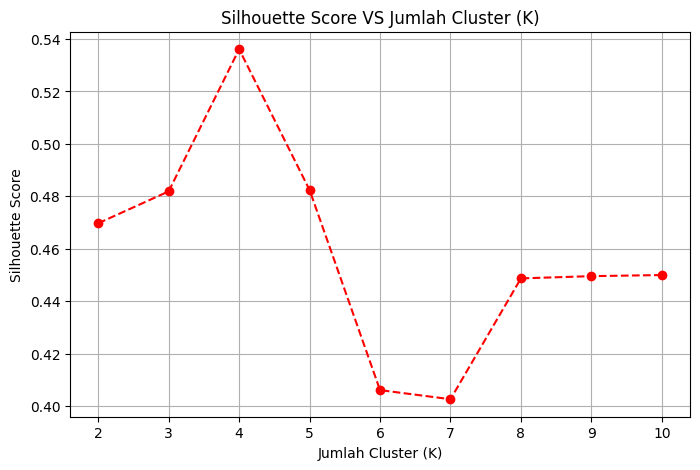

In [37]:
# Plot Grafik Silhouete Score
plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, marker='o', linestyle='--', color='red')
plt.title('Silhouette Score VS Jumlah Cluster (K)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

**CLUSTERING**

In [38]:
# k=4 karena dengan nilai sihoulette tertinggi
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

In [39]:
rfm

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347,40,7,3314.73,0
12348,220,3,90.20,1
12349,19,1,984.15,0
12350,311,1,294.40,1
12352,73,7,1130.94,0
...,...,...,...,...
18280,160,1,137.00,1
18281,4,1,46.92,0
18282,216,2,99.63,1


In [40]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,51.271852,3.461291,820.981981
1,261.752899,1.498662,313.284417
2,2.500000,147.500000,42091.010000
3,21.782946,18.426357,5034.310271


**Cluster 2 — High-Value Customers / VIP**

 **Karakteristik:**
- **Recency sangat rendah (2,5 hari)** → baru saja bertransaksi  
- **Frequency sangat tinggi (147)** → Pelanggan sangat sering berbelanja, jauh di atas cluster lainnya.
- **Monetary sangat tinggi (42.091)** → nilai pembelian terbesar di semua cluster

Kategori:
**High-Value Customers**

**Pelanggan Juara (Champions)**
Cluster ini mewakili inti dari kesuksesan Glossier Skincare. Mereka adalah pelanggan terbaik dan paling bernilai (RFM Score Tertinggi).

**Insight:**

Cluster ini merupakan pelanggan terbaik dan paling bernilai bagi bisnis. Mereka tidak hanya aktif (Recency Rendah), tetapi juga memiliki loyalitas tinggi (Frequency Tinggi) dan daya beli sangat besar (Monetary Tinggi). Kehilangan pelanggan dalam cluster ini akan berdampak besar terhadap pendapatan perusahaan.

**Strategi Bisnis:**

**1. Premium Membership:** Segera upgrade ke Program Loyalitas Gold/Diamond Glossier Skincare dengan benefit eksklusif.

**2. Layanan Prioritas:** Prioritaskan mereka dalam layanan pelanggan, pengiriman ekspres, dan undangan preview produk baru (VIP Access).

**3. Penawaran Eksklusif:** Kirimkan personalized gift atau penawaran produk edisi terbatas (tidak diskon) yang memvalidasi status mereka.

**Tujuan:**

Mempertahankan retention >95% dan mendorong advocacy.

---

**Cluster 3 — Loyal Mid-Value Customers / Potential High-Value**

 **Karakteristik:**
- **Recency rendah (21 Hari)** → pelanggan aktif  
- **Frequency cukup tinggi (18,43)**  
- **Monetary tinggi (5.034)** →
Nilai belanja relatif besar, meskipun masih di bawah cluster VIP

 Kategori:
**Loyal Customers / Potential High-Value**

**Pelanggan Setia**
Mereka adalah pelanggan reguler yang menyukai merek Anda tetapi belum mencapai tingkat spending Pelanggan Juara. Mereka memiliki potensi up-selling yang sangat tinggi.

**Insight:**

Cluster ini memiliki Frequency Tinggi dan Recency yang baik, tetapi nilai Monetary masih bisa ditingkatkan. Mereka adalah pengguna rutin yang puas, dan fokus strategi harus diarahkan pada peningkatan nilai transaksi rata-rata (AOV).

**Strategi Bisnis:**

**1. Rekomendasi Rutinitas Step-up:** Jika mereka rutin membeli cleanser, rekomendasikan serum atau toner pelengkap (produk bernilai lebih tinggi) melalui personalized email.

**2. Smart Bundling:** Tawarkan bundling produk yang saling melengkapi (misalnya, paket night routine) dengan sedikit insentif, bukan diskon besar.

**3. Uji Coba Produk Baru:** Beri mereka sample size dari produk premium yang baru diluncurkan.

**Tujuan:**

Meningkatkan Monetary mereka sebesar 10% dan mendorong up-selling produk bernilai tinggi.

---

** Cluster 0 — Active Low-Spenders**

 **Karakteristik:**
- **Recency menengah (51,27 hari)** → masih aktif  
- **Frequency rendah (3.46)**  
- **Monetary menengah (820)**  

 Kategori:
**Active Low-Spenders / Regular Customers**

**Pembeli Frekuentif (Frequent Buyers)**
Segmen ini aktif dan sering membeli, tetapi nilai setiap transaksi mereka cenderung kecil. Mereka sangat responsif terhadap promosi.

**Insight:**

Cluster ini sering berinteraksi dengan merek (Frequency Tinggi) dan Recency mereka bagus, tetapi nilai belanjanya (Monetary) rendah. Mereka cenderung membeli produk low-cost atau saat ada diskon kecil. Mereka price-sensitive.

**Strategi Bisnis:**

**1. Edukasi Nilai:** Alih-alih diskon, fokus pada edukasi tentang manfaat produk premium (misalnya, webinar singkat tentang skincare investment).

**2. Sample Kits Produk Premium:** Kirimkan sample kits dari produk mahal sebagai bagian dari pembelian berikutnya. Tujuannya adalah membuat mereka mencoba, menyukai, dan membeli produk bernilai tinggi di masa depan.

**3. Target Threshold:** Tawarkan insentif kecil (misalnya, free shipping) jika mereka mencapai nilai transaksi tertentu yang sedikit lebih tinggi dari AOV mereka saat ini.

**Tujuan:**

Mengonversi frekuensi menjadi nilai, meningkatkan Monetary jangka panjang.

---
**Cluster 1 — Inactive / Low-Value Customers**

 **Karakteristik:**
- **Recency sangat tinggi (261,75 hari)** → sudah lama tidak berbelanja  
- **Frequency sangat rendah (1.50)**  
- **Monetary rendah (313)**  

 Kategori:
**Inactive Customers / At-Risk / Lost Customers**

**Pelanggan Berisiko**
Ini adalah segmen krusial yang perlu diintervensi segera untuk mencegah churn permanen.

**Insight:**

Cluster ini memiliki Recency Tinggi (Lama tidak berbelanja) dan Monetary yang bervariasi. Mereka adalah pelanggan yang nilainya sedang hingga tinggi di masa lalu, tetapi kini menunjukkan tanda-tanda menghilang. Kehilangan mereka adalah kerugian yang dapat dicegah.

**Strategi Bisnis:**

Voucher Reaktivasi Kuat: Kirimkan Voucher Diskon Besar (misalnya, 30%) yang sangat kuat.

**1. Unsur Urgensi:** Tambahkan Batas Waktu yang ketat (expired in 7 days) dan narasi personal, seperti: "Kami Merindukan Rutinitas Kulit Anda, Gunakan Voucher Ini Sekarang!"

**2. Survei Reaktivasi:** Jika mereka tidak merespons voucher, kirimkan survei singkat untuk memahami alasan churn (misalnya, pindah merek, masalah kualitas, harga).

**Tujuan:**

Reaktivasi segera (target 15%) dan mencegah churn menjadi permanen.


**Visualisasi Cluster**

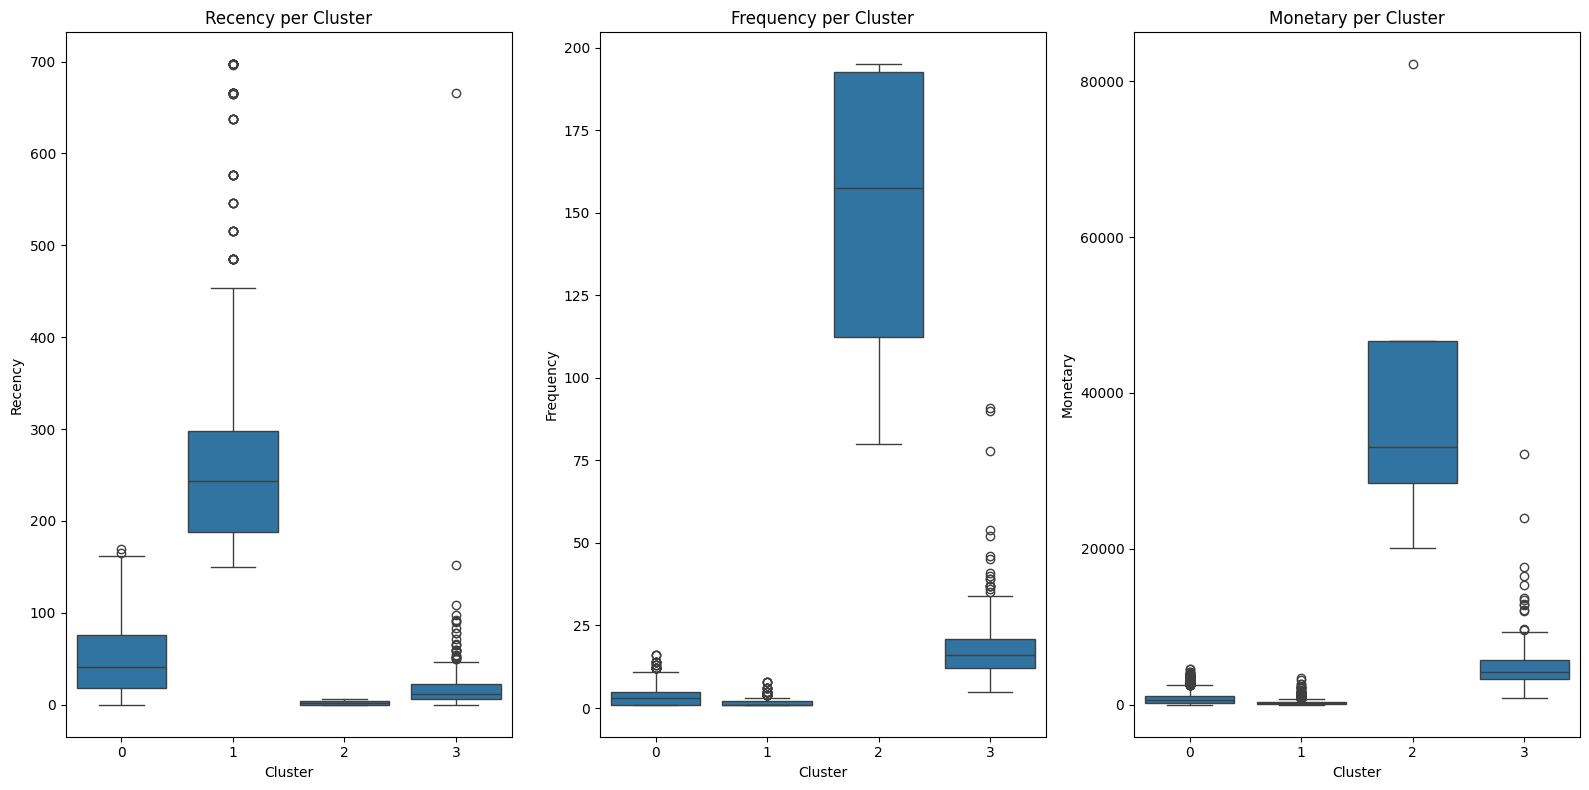

In [41]:
plt.figure(figsize=(16,8))

plt.subplot(131)
sns.boxplot(x='Cluster', y='Recency', data=rfm)
plt.title("Recency per Cluster")

plt.subplot(132)
sns.boxplot(x='Cluster', y='Frequency', data=rfm)
plt.title("Frequency per Cluster")

plt.subplot(133)
sns.boxplot(x='Cluster', y='Monetary', data=rfm)
plt.title("Monetary per Cluster")

plt.tight_layout()
plt.show()

**1. Outlier pada Monetary**
- Muncul karena beberapa pelanggan melakukan pembelian dalam jumlah besar.
- Mewakili pelanggan high-value seperti reseller atau pembeli grosir.
- Informasi penting karena menunjukkan kontribusi pelanggan prioritas.

**2. Outlier pada Frequency**
- Disebabkan oleh pelanggan yang sering melakukan transaksi berulang.
- Menggambarkan kelompok pelanggan loyal.
- Tidak boleh dihapus karena berpengaruh pada segmentasi pelanggan.

**3. Outlier pada Recency**
- Nilai Recency tinggi menunjukkan pelanggan tidak aktif dalam waktu lama.
- Penting untuk mengidentifikasi pelanggan yang perlu strategi re-engagement.

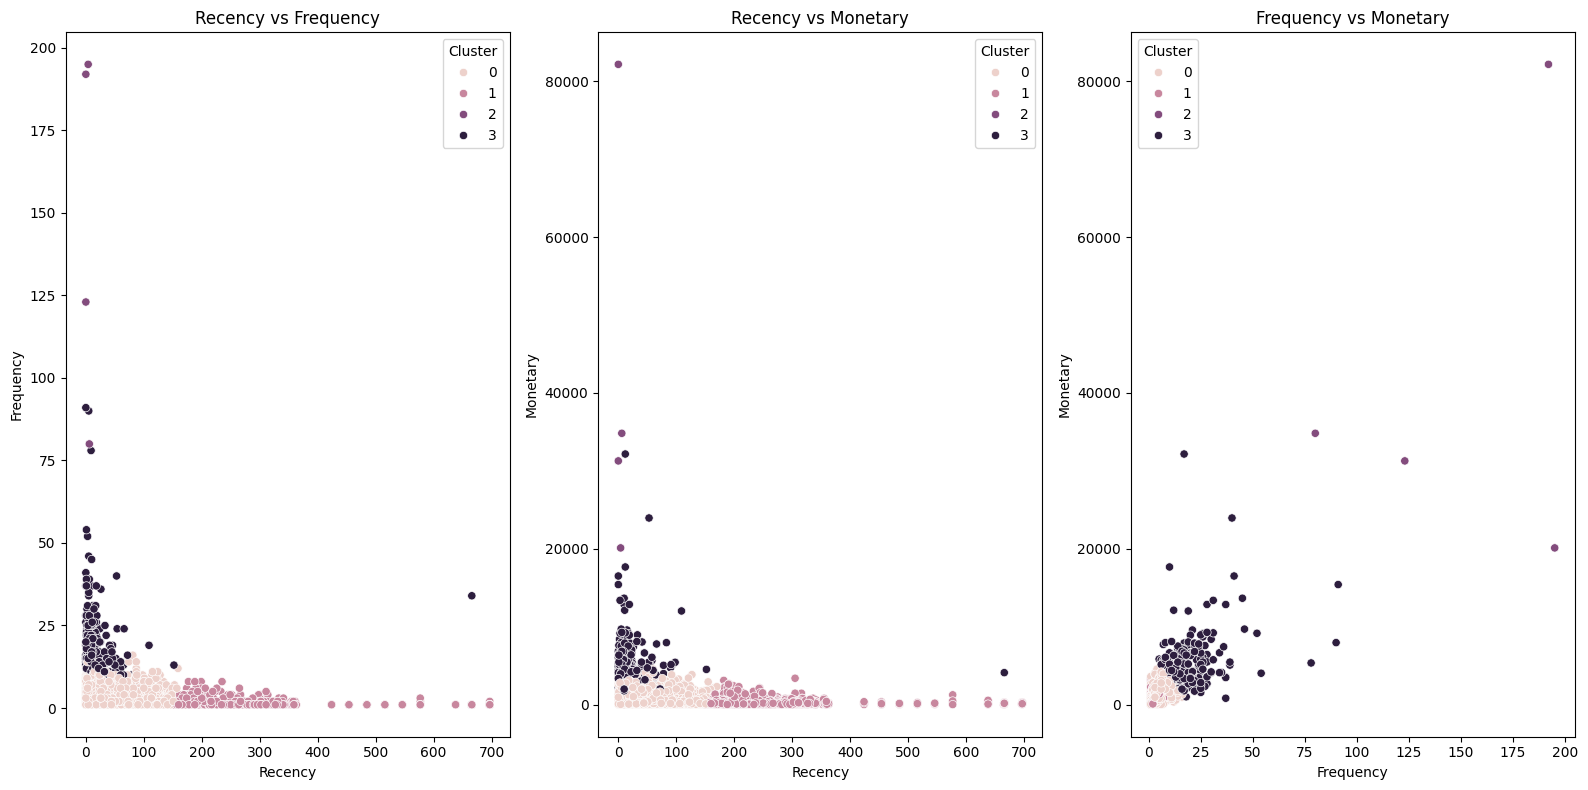

In [42]:
plt.figure(figsize=(16,8))

plt.subplot(131)
sns.scatterplot(x='Recency', y='Frequency', hue='Cluster', data=rfm)
plt.title("Recency vs Frequency")

plt.subplot(132)
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm)
plt.title("Recency vs Monetary")

plt.subplot(133)
sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', data=rfm)
plt.title("Frequency vs Monetary")

plt.tight_layout()
plt.show()

**  1. Scatter Plot: Recency vs Frequency**

Plot ini menunjukkan hubungan antara:
- Recency → waktu sejak terakhir transaksi
- Frequency → seberapa sering pelanggan bertransaksi


- **Cluster 2 (High-Value)**  
  - Frequency sangat tinggi (hingga >100).  
  - Recency sangat rendah.  
  - Pelanggan sangat aktif dan bertransaksi dalam jumlah besar.

- **Cluster 3 (Loyal Medium-High Value Customers)**  
  - Frequency menengah (10–50).  
  - Recency rendah.  
  - Pelanggan aktif dan loyal dengan kontribusi stabil.

- **Cluster 1 (Inactive / Lost Customers)**  
  - Frequency sangat rendah dan Recency sangat tinggi.  
  - Pelanggan sudah lama tidak kembali bertransaksi.  

- **Cluster 0 (Active Low-Spenders)**  
  - Recency rendah–menengah namun Frequency rendah.  
  - Pelanggan masih aktif namun nilai belanjanya kecil.

---

**  2. Scatter Plot: Recency vs Monetary**

Plot ini menunjukkan hubungan antara:
- Recency
- Monetary → total nilai transaksi pelanggan


- **Cluster 2 (High-Value)**  
  - Monetary sangat tinggi, termasuk outlier >80.000.  
  - Pelanggan ini adalah penyumbang pendapatan terbesar.

- **Cluster 3 (Loyal Medium-High Value)**  
  - Monetary menengah (1.000–10.000).  
  - Pelanggan loyal dengan kontribusi signifikan.

- **Cluster 1 (Inactive Customers)**  
  - Monetary rendah, Recency tinggi.  
  - Pelanggan dengan nilai transaksi kecil dan tidak aktif.

- **Cluster 0 (Active Low-Spenders)**  
  - Monetary rendah meskipun Recency rendah.  
  - Pelanggan aktif namun pembelanjaan kecil.

---

**  3. Scatter Plot: Frequency vs Monetary**

Plot ini menunjukkan hubungan antara:
- Frequency
- Monetary


- **Cluster 2 (High-Value Customers)**  
  - Frequency dan Monetary tertinggi.  
  - Outlier transaksi besar semuanya berada pada cluster ini.  
  - Merupakan pelanggan VIP yang sangat bernilai.

- **Cluster 3 (Loyal Medium-High Value)**  
  - Frequency cukup tinggi dan Monetary menengah.  
  - Menunjukkan pelanggan loyal yang rutin berbelanja.

- **Cluster 1 (Inactive / Low-Value)**  
  - Frequency rendah, Monetary rendah.  
  - Jarang bertransaksi dan tidak memberikan kontribusi besar.

- **Cluster 0 (Active Low-Spenders)**  
  - Frequency rendah & Monetary rendah.  
  - Pelanggan baru atau pembeli bernilai rendah.

<Axes: xlabel='pca1', ylabel='pca2'>

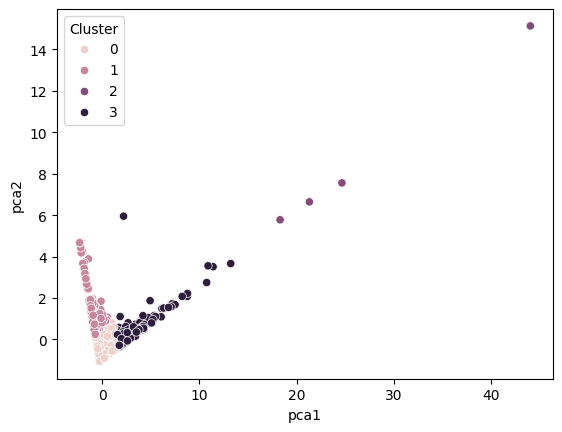

In [43]:
# PCA
pca = PCA(n_components=2)
pca_res = pca.fit_transform(rfm_scaled_df)

rfm['pca1'] = pca_res[:,0]
rfm['pca2'] = pca_res[:,1]

sns.scatterplot(x='pca1', y='pca2', hue='Cluster', data=rfm)

**1. Cluster 2 — High-Value**
- Titik-titik cluster 2 berada jauh ke kanan (nilai PCA1 besar).
- Hal ini terjadi karena cluster ini memiliki Frequency dan Monetary yang sangat tinggi, sehingga berdampak besar pada PCA1.
- Titik-titik ekstrem di sisi kanan grafik mencerminkan pelanggan dengan nilai transaksi sangat besar.

**2. Cluster 3 — Loyal Medium-High Value**
- Terdistribusi secara diagonal ke bagian tengah grafik.
- Menunjukkan pelanggan yang aktif dan loyal, dengan kontribusi nilai transaksi menengah–tinggi.
- Persebarannya cukup stabil dan tidak terlalu ekstrem.

**3. Cluster 0 — Active Low-Spenders**
- Mengelompok pada area kiri bawah.
- Karakteristiknya adalah spending rendah dan frekuensi rendah.
- RFM mereka menghasilkan skor PCA rendah, sehingga terkonsentrasi pada bagian bawah grafik.

**4. Cluster 1 — Inactive / Lost Customers**
- Titik-titiknya sangat berdekatan di area kiri tengah.
- Memiliki Recency tinggi dan Frequency rendah.
- Karena hampir tidak bertransaksi, nilai PCA mereka cenderung kecil dan berkumpul rapat.


In [44]:
import joblib
joblib.dump(kmeans, 'kmeans_rfm_model.pkl')
joblib.dump(scaler, 'rfm_scaler.pkl')

['rfm_scaler.pkl']

In [45]:
from google.colab import files

files.download('kmeans_rfm_model.pkl')
files.download('rfm_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>